## Assignment : 17 Timeseries

Part 1: Data Preparation and Exploration

1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.
2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.
3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('exchange_rate.csv')
df

,date,Ex_rate
0,01-01-1990 00:00,0.785500
1,02-01-1990 00:00,0.781800
2,03-01-1990 00:00,0.786700
3,04-01-1990 00:00,0.786000
4,05-01-1990 00:00,0.784900
...,...,...
7583,06-10-2010 00:00,0.718494
7584,07-10-2010 00:00,0.721839
7585,08-10-2010 00:00,0.723197
7586,09-10-2010 00:00,0.720825


In [3]:
df.isnull().sum()

date       0
Ex_rate    0
dtype: int64

In [4]:
df.describe()

,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7588 entries, 0 to 7587
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   date     7588 non-null   object 
 1   Ex_rate  7588 non-null   float64
dtypes: float64(1), object(1)
memory usage: 118.7+ KB


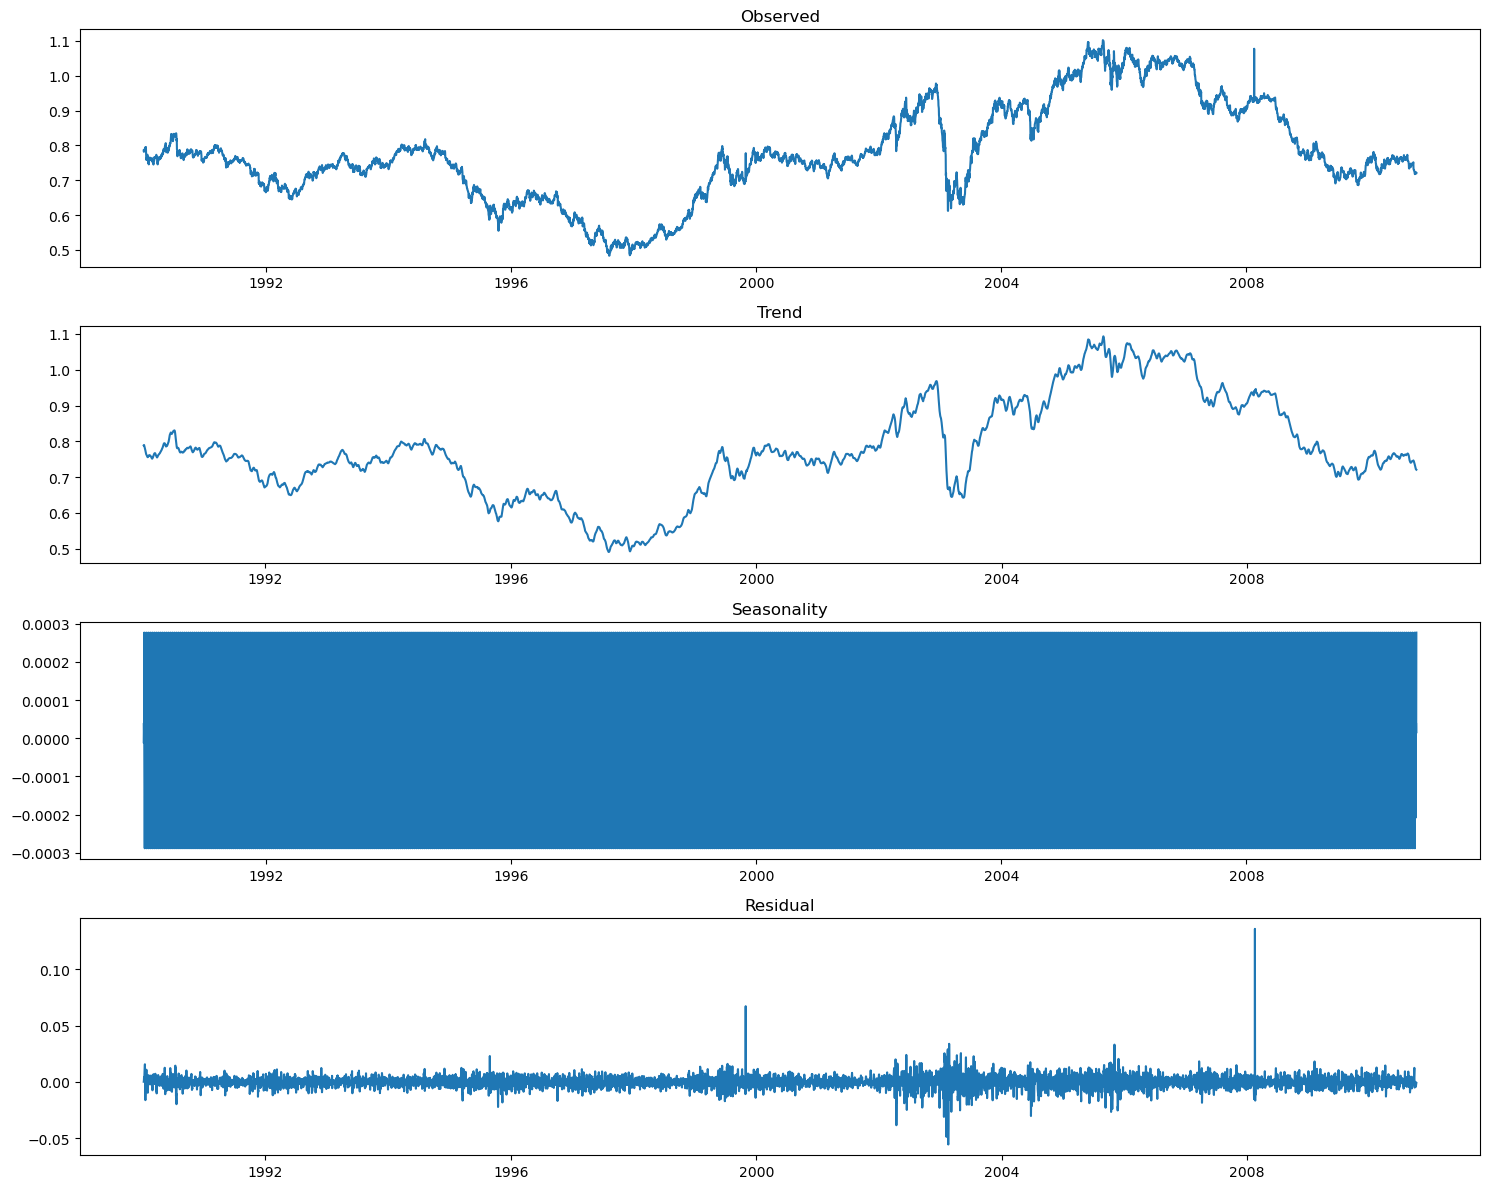

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Convert date column to datetime
df['date'] = pd.to_datetime(
    df['date'],
    format='%d-%m-%Y %H:%M'
)

# Set date as index
df.set_index('date', inplace=True)

# Perform seasonal decomposition
decomposition = seasonal_decompose(
    df['Ex_rate'], 
    model='additive', 
    period=12
)

# Create figure with 4 subplots
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

# Plot observed data
axes[0].plot(decomposition.observed)
axes[0].set_title("Observed")

# Plot trend
axes[1].plot(decomposition.trend)
axes[1].set_title("Trend")

# Plot seasonal component
axes[2].plot(decomposition.seasonal)
axes[2].set_title("Seasonality")

# Plot residual component
axes[3].plot(decomposition.resid)
axes[3].set_title("Residual")

plt.tight_layout()
plt.show()


Part 2: Model Building - ARIMA

1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.
2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.
3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.
4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.


In [7]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import itertools

In [8]:
ts = df['Ex_rate']

In [9]:
adf_result = adfuller(ts)
print("ADF p-value:", adf_result[1])

ADF p-value: 0.44923273535982894


In [10]:
ts_diff = ts.diff().dropna()

Text(0.5, 1.0, 'ACF Plot')

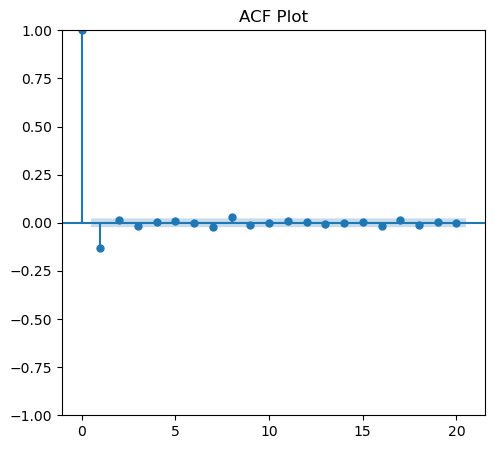

In [11]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plot_acf(ts_diff, lags=20, ax=plt.gca())
plt.title("ACF Plot")

Text(0.5, 1.0, 'PACF Plot')

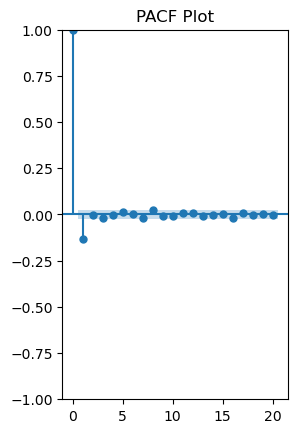

In [12]:
plt.subplot(1,2,2)
plot_pacf(ts_diff, lags=20, ax=plt.gca(), method='ywm')
plt.title("PACF Plot")

In [13]:
model = ARIMA(ts, order=(1,1,1))
model_fit = model.fit()

C:\Users\lenovo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\lenovo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\lenovo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\lenovo\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [14]:
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                Ex_rate   No. Observations:                 7588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               28054.161
Date:                Wed, 07 Jan 2026   AIC                         -56102.322
Time:                        15:56:38   BIC                         -56081.519
Sample:                    01-01-1990   HQIC                        -56095.182
                         - 10-10-2010                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1268      0.045     -2.797      0.005      -0.216      -0.038
ma.L1         -0.0046      0.045     -0.101      0.920      -0.094       0.085
sigma2      3.596e-05   9.94e-08    361.604      0.000    3.58e-05    3.62e-05
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):           2865078.33
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               2.97   Skew:                             0.24
Prob(H) (two-sided):                  0.00   Kurtosis:                        98.20
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

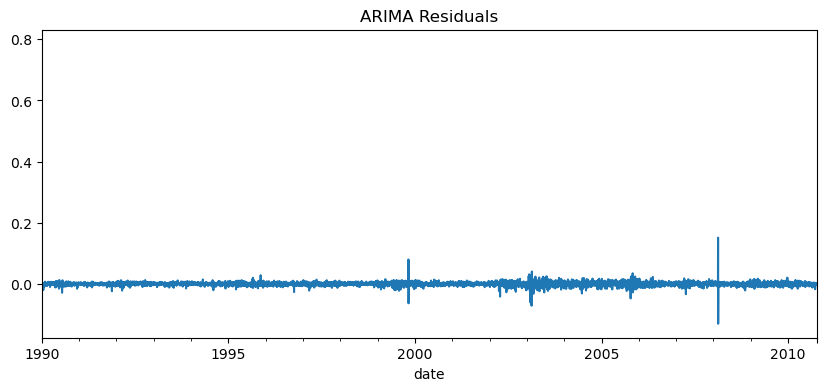

In [15]:
model_fit.resid.plot(figsize=(10,4))
plt.title("ARIMA Residuals")
plt.show()

In [16]:
residuals = model_fit.resid

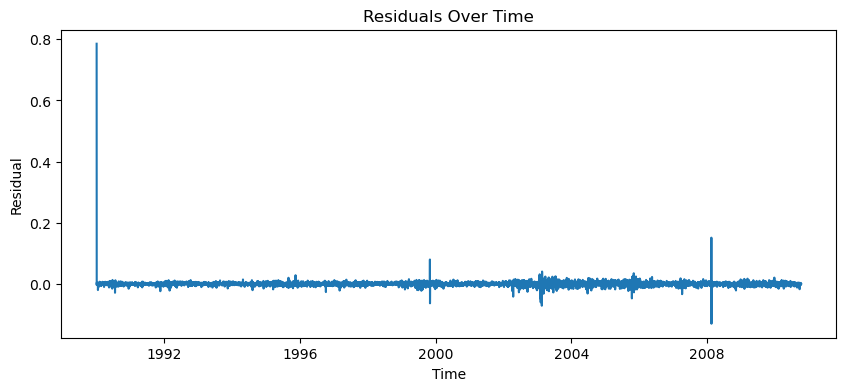

In [17]:
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("Residuals Over Time")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()

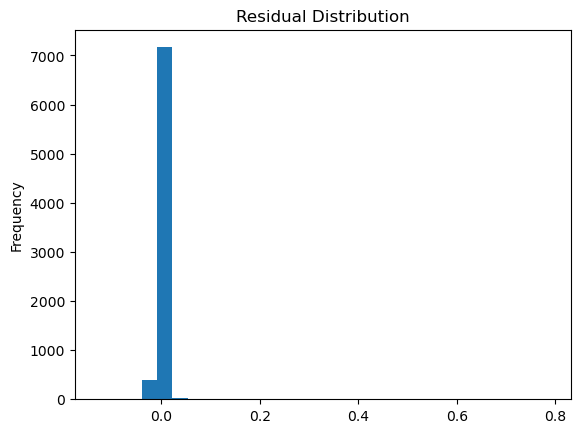

In [18]:
residuals.plot(kind='hist', bins=30, title="Residual Distribution")
plt.show()

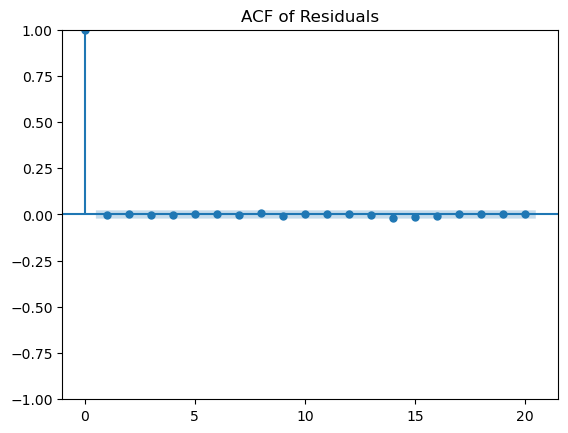

In [19]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals, lags=20)
plt.title("ACF of Residuals")
plt.show()

In [20]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(ljung_box)

    lb_stat  lb_pvalue
10  1.81673   0.997562


In [21]:
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

In [28]:
# Fit Exponential Smoothing model

from statsmodels.tsa.holtwinters import ExponentialSmoothing

exp_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal=None
)

exp_fit = exp_model.fit()

C:\Users\lenovo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [29]:
exp_forecast = exp_fit.forecast(len(test))

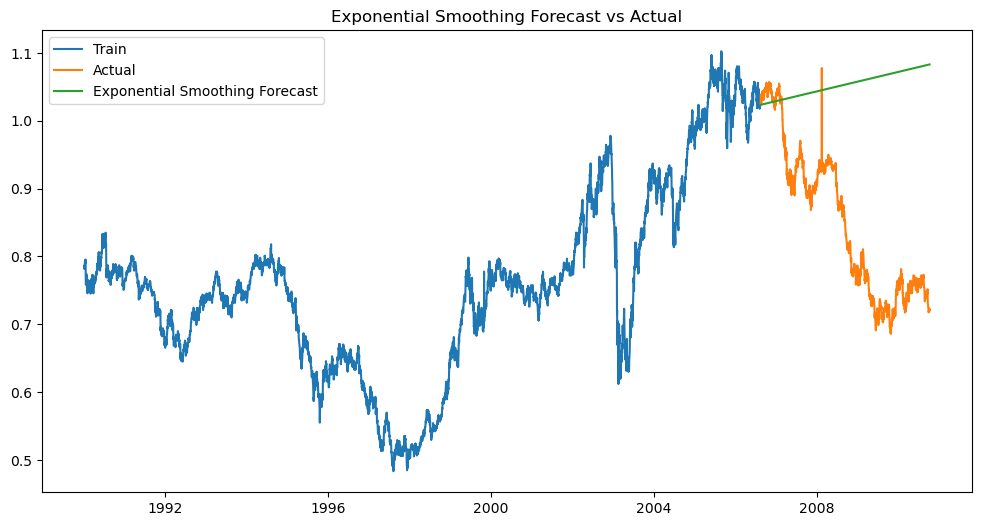

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual")
plt.plot(exp_forecast.index, exp_forecast, label="Exponential Smoothing Forecast")
plt.legend()
plt.title("Exponential Smoothing Forecast vs Actual")
plt.show()

In [31]:
forecast_steps = len(test)
forecast = model_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()

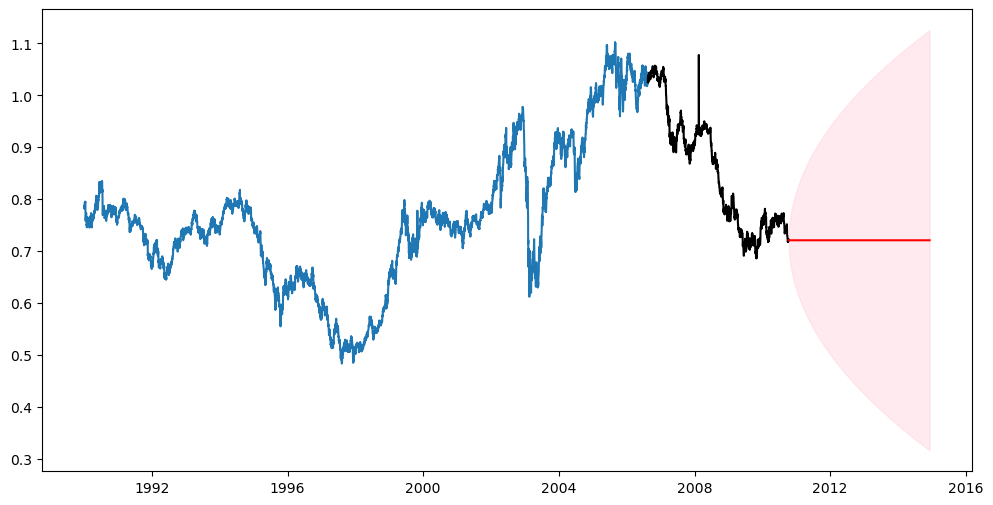

In [32]:
plt.figure(figsize=(12,6))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(forecast_mean.index, forecast_mean, label="Forecast", color="red")

# Confidence interval
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:, 0],
    conf_int.iloc[:, 1],
    color="pink",
    alpha=0.3,
    label="Confidence Interval"
)

In [33]:
# Hyperparameter Tuning Using AIC (Grid Search)
best_aic = float("inf")
best_model = None
best_params = None

for trend in ['add', None]:
    for seasonal in [None, 'add']:
        try:
            model = ExponentialSmoothing(
                train,
                trend=trend,
                seasonal=seasonal,
                seasonal_periods=12 if seasonal else None
            )
            fit = model.fit()
            if fit.aic < best_aic:
                best_aic = fit.aic
                best_model = fit
                best_params = (trend, seasonal)
        except:
            pass

print("Best Parameters:", best_params)
print("Best AIC:", best_aic)


C:\Users\lenovo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\lenovo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\lenovo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\lenovo\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Best Parameters: (None, None)
Best AIC: -62659.34327127156


Part 3: Evaluation and Comparison

1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.
2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.
3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_forecast(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return mae, rmse, mape

In [35]:
mae_arima, rmse_arima, mape_arima = evaluate_forecast(test, forecast_mean)

print("ARIMA Metrics")
print("MAE :", mae_arima)
print("RMSE:", rmse_arima)
print("MAPE:", mape_arima)

ARIMA Metrics
MAE : 0.13138711039574075
RMSE: 0.16946894668351717
MAPE: nan


In [36]:
mae_exp, rmse_exp, mape_exp = evaluate_forecast(test, exp_forecast)

print("Exponential Smoothing Metrics")
print("MAE:", mae_exp)
print("RMSE:", rmse_exp)
print("MAPE:", mape_exp)

Exponential Smoothing Metrics
MAE: 0.20659619216588007
RMSE: 0.23910443281197072
MAPE: 26.508663930344888


In [37]:
mape = np.mean(np.abs((test - forecast_mean) / (test + 1e-8))) * 100
print("MAPE:", mape)

MAPE: nan


# Model Comparison
1)ARIMA Model

- Shows lower MAE and RMSE, indicating better forecasting accuracy.

- Effectively captures trend and short-term dependencies in exchange rates.

- Performs well for non-seasonal time-series data.

Limitations: Does not explicitly handle seasonality and assumes linear relationships.

2)Exponential Smoothing Model

- Simple and robust for level-based and trend forecasting.

- Works well when the time series shows smooth trends.

- Requires fewer assumptions compared to ARIMA.

Limitations: Less effective in capturing complex patterns and sudden fluctuations.

3)Overall Comparison

- ARIMA provides more accurate forecasts based on error metrics.

- Exponential Smoothing offers simplicity and stability, but slightly lower accuracy.

- Choice of model depends on data complexity and forecasting requirements.


# Conclusion

- ARIMA performed well in capturing short-term dependencies and trends.

- Exponential Smoothing provided competitive results for level-based forecasting.

- Hyperparameter tuning using AIC improved model selection.

Overall, ARIMA showed better accuracy, while Exponential Smoothing offered simplicity and robustness.